# Perceptron Learning in 2D

## What is a perceptron?

A **perceptron** is the simplest neural network — a single neuron that learns a linear decision boundary from labelled examples.

**Model.** Given an input $\mathbf{x} \in \mathbb{R}^d$, the perceptron computes a weighted sum and applies a sign function:

$$\hat{y} = \text{sign}(\mathbf{w} \cdot \mathbf{x} + b)$$

where $\mathbf{w}$ is the weight vector and $b$ is the bias. The output is $+1$ or $-1$.

**Learning rule.** When the perceptron misclassifies a point $(x_i, y_i)$, it nudges the weights toward the correct answer:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \, y_i \, \mathbf{x}_i, \qquad b \leftarrow b + \eta \, y_i$$

where $\eta$ is the **learning rate** (how big each correction step is).

**Convergence theorem.** If the data is linearly separable, the perceptron is guaranteed to converge (find a perfect boundary) in a finite number of updates. If the data is *not* linearly separable, it will keep updating indefinitely.

---

This notebook:
- generates a random 2D dataset split by a hidden line
- implements the perceptron learning rule from scratch
- visualizes how the decision boundary evolves during training

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.style.use("seaborn-v0_8-whitegrid")


In [ ]:
def make_linearly_separable_data(n_samples=50, seed=7, margin=0.8, noise_points=0):
    """Generate random 2D points labelled by which side of a hidden line they fall on.

    Parameters
    ----------
    n_samples : int
        Number of clean data points to generate.
    seed : int
        Random seed for reproducibility.
    margin : float
        Minimum distance from the hidden line — keeps the two classes visually separated.
    noise_points : int
        Number of points whose labels are flipped to create contradictory examples.

    Returns
    -------
    X : ndarray of shape (n_samples + noise_points, 2)
    y : ndarray of shape (n_samples + noise_points,) with values +1 / -1
    true_w, true_b : the hidden line parameters (for plotting)
    noisy_mask : boolean array marking which points have flipped labels
    """
    rng = np.random.default_rng(seed)

    # Hidden line that defines the "true" boundary.
    true_w = np.array([1.2, -0.8])
    true_b = 0.3

    points = []
    labels = []

    while len(points) < n_samples:
        point = rng.uniform(-4.0, 4.0, size=2)
        score = np.dot(true_w, point) + true_b

        # Skip points too close to the line so the classes are clearly separated.
        if abs(score) < margin:
            continue

        points.append(point)
        labels.append(1 if score > 0 else -1)

    X = np.array(points)
    y = np.array(labels)

    # Shuffle so the learning order looks random.
    order = rng.permutation(n_samples)
    X, y = X[order], y[order]
    noisy_mask = np.zeros(len(X), dtype=bool)

    if noise_points > 0:
        # Sample from both classes so noisy points aren't one-sided.
        pos_indices = np.where(y == 1)[0]
        neg_indices = np.where(y == -1)[0]
        n_from_pos = noise_points // 2
        n_from_neg = noise_points - n_from_pos
        # If one class doesn't have enough points, take the rest from the other.
        n_from_pos = min(n_from_pos, len(pos_indices))
        n_from_neg = min(n_from_neg, len(neg_indices))
        # Fill any shortfall from the other class.
        if n_from_pos + n_from_neg < noise_points:
            shortfall = noise_points - n_from_pos - n_from_neg
            if n_from_pos < noise_points // 2:
                n_from_neg = min(n_from_neg + shortfall, len(neg_indices))
            else:
                n_from_pos = min(n_from_pos + shortfall, len(pos_indices))

        flip_indices = np.concatenate([
            rng.choice(pos_indices, size=n_from_pos, replace=False),
            rng.choice(neg_indices, size=n_from_neg, replace=False),
        ])

        noisy_X = X[flip_indices].copy()
        noisy_y = -y[flip_indices]

        X = np.vstack([X, noisy_X])
        y = np.concatenate([y, noisy_y])
        noisy_mask = np.concatenate([noisy_mask, np.ones(noise_points, dtype=bool)])

        # Shuffle again so noisy points are mixed in.
        order = rng.permutation(len(X))
        X, y, noisy_mask = X[order], y[order], noisy_mask[order]

    return X, y, true_w, true_b, noisy_mask

In [ ]:
# ---------------------------------------------------------------------------
# Plotting helpers (used by several cells below)
# ---------------------------------------------------------------------------

def plot_points(ax, X, y, noisy_mask=None):
    """Draw the two classes and optionally mark noisy examples."""
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=60, color="tab:blue", label="class +1")
    ax.scatter(X[y == -1, 0], X[y == -1, 1], s=60, color="tab:orange", label="class −1")

    if noisy_mask is not None and noisy_mask.any():
        # Color each noisy marker by its (flipped) label so the contradiction
        # is visible: e.g. a blue X sitting in the orange region.
        noisy_colors = ["tab:blue" if yi == 1 else "tab:orange" for yi in y[noisy_mask]]
        ax.scatter(
            X[noisy_mask, 0],
            X[noisy_mask, 1],
            s=120,
            color=noisy_colors,
            marker="x",
            linewidths=2,
            label="noisy (flipped)",
        )

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(loc="upper left")


def decision_line_points(w, b, x_limits, y_limits):
    """Convert perceptron weights into two endpoints of the decision boundary.

    The boundary is the line where w1*x1 + w2*x2 + b = 0.
    Returns None when the weights are all zero (no boundary yet).
    """
    # At initialization all weights are zero — nothing to draw.
    if np.allclose(w, 0):
        return None

    if abs(w[1]) > 1e-12:
        x_vals = np.array(x_limits)
        y_vals = -(w[0] * x_vals + b) / w[1]
        return x_vals, y_vals

    # Vertical boundary (w2 ≈ 0).
    if abs(w[0]) > 1e-12:
        x_val = -b / w[0]
        return np.array([x_val, x_val]), np.array(y_limits)

    return None


def draw_boundary(ax, w, b, x_limits, y_limits, **plot_kwargs):
    """Draw the decision boundary and lock the axis limits."""
    pts = decision_line_points(w, b, x_limits, y_limits)
    if pts is not None:
        ax.plot(*pts, **plot_kwargs)
    ax.set_xlim(*x_limits)
    ax.set_ylim(*y_limits)

In [ ]:
# Change this to inject contradictory labels and see what happens when the
# dataset is NOT linearly separable (try noise_points = 3 or 5).
noise_points = 0

X, y, true_w, true_b, noisy_mask = make_linearly_separable_data(
    n_samples=50,
    seed=7,
    noise_points=noise_points,
)
x_limits = (X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
y_limits = (X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

dataset_type = (
    "linearly separable"
    if noise_points == 0
    else f"not fully separable ({noise_points} noisy points)"
)

print(f"Dataset: {X.shape[0]} points, {dataset_type}")

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_points(ax, X, y, noisy_mask)
draw_boundary(
    ax, true_w, true_b, x_limits, y_limits,
    color="gray", linestyle="--", linewidth=2, label="hidden target line",
)
ax.set_title("Dataset with hidden decision boundary")
ax.legend(loc="lower right")
plt.show()

## Training the perceptron

The algorithm below loops over the dataset epoch by epoch. For each point it checks whether the current weights classify it correctly. If not, it applies the update rule:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \, y_i \, \mathbf{x}_i, \qquad b \leftarrow b + \eta \, y_i$$

We use a **learning rate** $\eta = 1$ (the classic perceptron). Larger values make bigger corrections per mistake; smaller values make the boundary move more gradually. With $\eta = 1$ each update moves the weight vector by exactly the misclassified point's contribution.

In [ ]:
def perceptron_train(X, y, learning_rate=1.0, max_epochs=20):
    """Train a perceptron on dataset (X, y) using the classic update rule.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Training inputs.
    y : ndarray of shape (n_samples,)
        Labels, +1 or -1.
    learning_rate : float
        Step size for each weight update (eta).
    max_epochs : int
        Stop after this many passes through the dataset.

    Returns
    -------
    w, b : learned weights and bias
    history : list of dicts recording every weight update (for visualization)
    mistakes_per_epoch : list of ints, one entry per epoch
    converged : True if the perceptron classified every point correctly
    """
    # Start with zero weights and bias.
    w = np.zeros(X.shape[1], dtype=float)
    b = 0.0

    # Save every update so we can visualize the learning process later.
    history = [{"w": w.copy(), "b": b, "sample_idx": None, "epoch": 0}]
    mistakes_per_epoch = []
    converged = False

    for epoch in range(1, max_epochs + 1):
        mistakes = 0

        for i, (x_i, y_i) in enumerate(zip(X, y)):
            # Predict: ŷ = sign(w · x + b)
            score = np.dot(w, x_i) + b
            prediction = 1 if score >= 0 else -1

            if prediction != y_i:
                # Update rule: nudge w and b toward the correct class.
                w = w + learning_rate * y_i * x_i
                b = b + learning_rate * y_i
                mistakes += 1

                history.append({"w": w.copy(), "b": b, "sample_idx": i, "epoch": epoch})

        mistakes_per_epoch.append(mistakes)

        # Stop early once every point is classified correctly.
        if mistakes == 0:
            converged = True
            break

    return w, b, history, mistakes_per_epoch, converged


# Allow more epochs when noise makes perfect separation impossible.
max_epochs = 20 if noise_points == 0 else 40

learned_w, learned_b, history, mistakes_per_epoch, converged = perceptron_train(
    X, y, max_epochs=max_epochs,
)

predictions = np.where(X @ learned_w + learned_b >= 0, 1, -1)
accuracy = (predictions == y).mean()

print(f"Learned weights: w = [{learned_w[0]:.2f}, {learned_w[1]:.2f}], b = {learned_b:.2f}")
print(f"Epochs run: {len(mistakes_per_epoch)}, total updates: {len(history) - 1}")
print(f"Training accuracy: {accuracy:.0%}")
if converged:
    print("Perceptron converged — all points classified correctly.")
else:
    print(f"Did not converge after {max_epochs} epochs (expected with noisy data).")

### Learning curve

The plot below shows how many mistakes the perceptron makes in each epoch. For a linearly separable dataset this should drop to zero; with noisy data it will fluctuate.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
epochs = range(1, len(mistakes_per_epoch) + 1)
ax.bar(epochs, mistakes_per_epoch, color="steelblue")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mistakes")
ax.set_title("Mistakes per epoch")
ax.set_xticks(list(epochs))
plt.tight_layout()
plt.show()

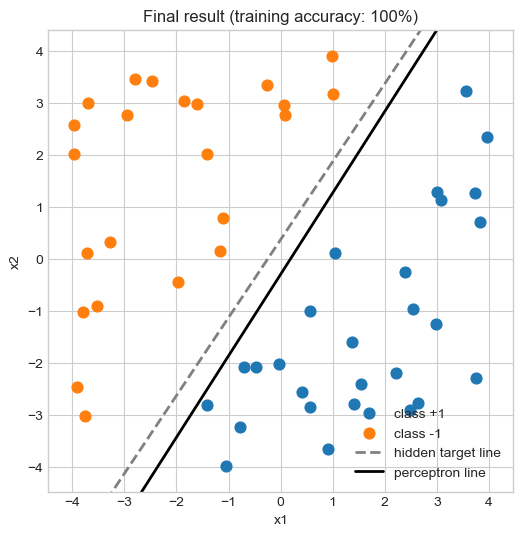

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_points(ax, X, y, noisy_mask)
draw_boundary(
    ax,
    true_w,
    true_b,
    x_limits,
    y_limits,
    color="gray",
    linestyle="--",
    linewidth=2,
    label="hidden target line",
)
draw_boundary(
    ax,
    learned_w,
    learned_b,
    x_limits,
    y_limits,
    color="black",
    linewidth=2,
    label="perceptron line",
)
ax.set_title(f"Final result (training accuracy: {accuracy:.0%})")
ax.legend(loc="lower right")
plt.show()


The next figure shows a few training snapshots. The red circle marks the point that caused the latest update.

If `noise_points > 0`, the black `x` markers show contradictory examples that prevent perfect separation.


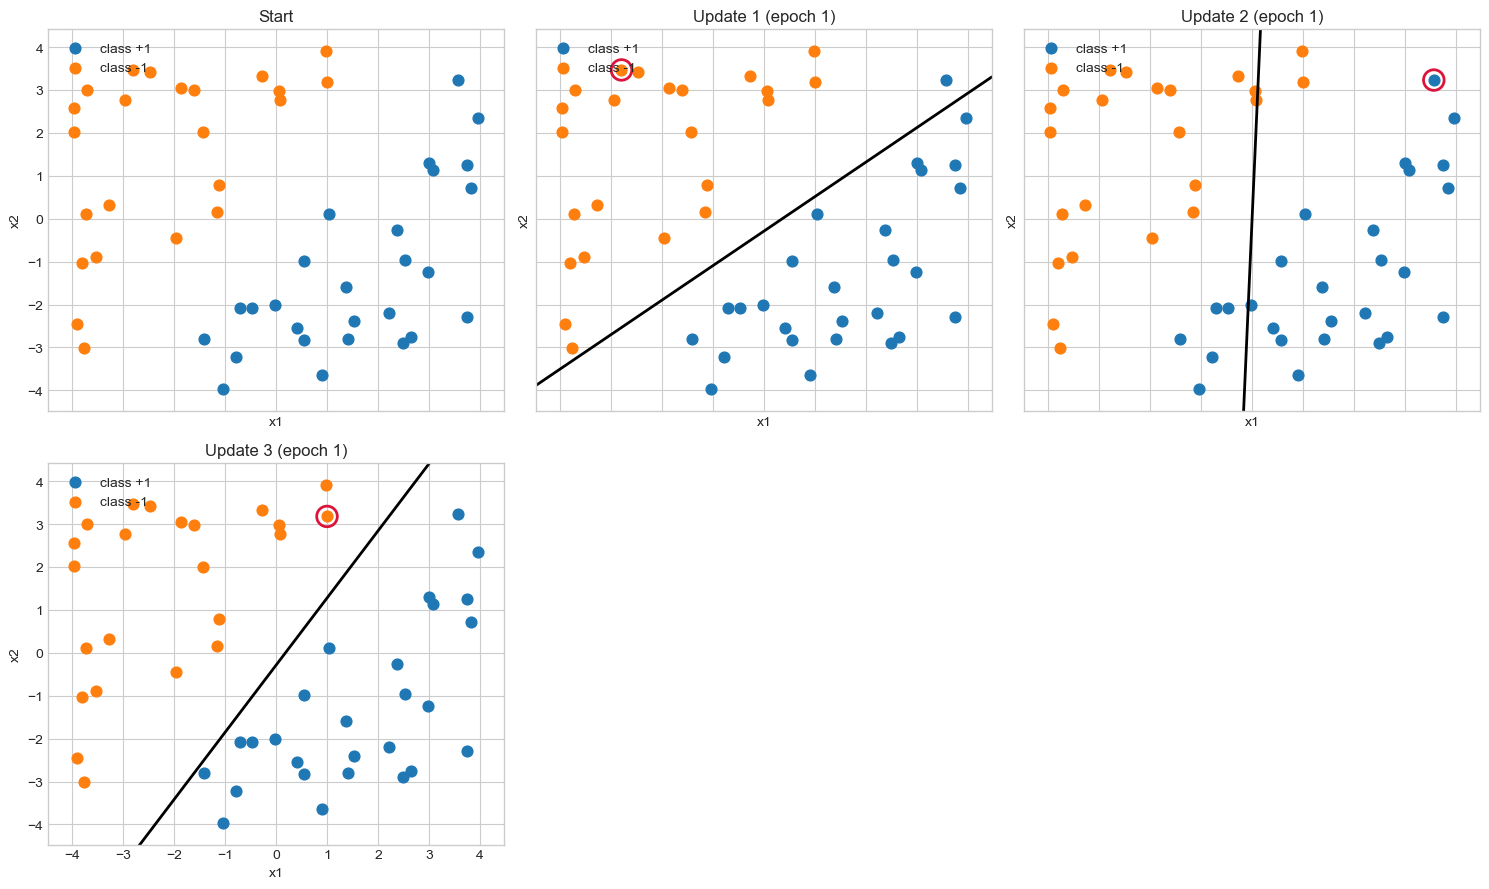

In [27]:
selected_frames = np.linspace(0, len(history) - 1, num=min(6, len(history)), dtype=int)
selected_frames = np.unique(selected_frames)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, frame in zip(axes, selected_frames):
    state = history[frame]
    plot_points(ax, X, y, noisy_mask)
    draw_boundary(
        ax,
        state["w"],
        state["b"],
        x_limits,
        y_limits,
        color="black",
        linewidth=2,
    )

    if state["sample_idx"] is not None:
        point = X[state["sample_idx"]]
        ax.scatter(
            point[0],
            point[1],
            s=220,
            facecolors="none",
            edgecolors="crimson",
            linewidths=2,
        )

    if frame == 0:
        ax.set_title("Start")
    else:
        ax.set_title(f"Update {frame} (epoch {state['epoch']})")

for ax in axes[len(selected_frames):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


This animation shows the perceptron updates. The red circle highlights the point that was misclassified before the update happened.

For long noisy runs, the animation samples the history so it stays responsive inside the notebook.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_points(ax, X, y, noisy_mask)

line, = ax.plot([], [], color="black", linewidth=2, label="perceptron line")
focus = ax.scatter([], [], s=220, facecolors="none", edgecolors="crimson", linewidths=2)
status_text = ax.text(
    0.02, 0.98, "",
    transform=ax.transAxes, va="top", ha="left",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9, "edgecolor": "0.7"},
)

ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_title("Perceptron learning")
ax.legend(loc="lower right")

# Subsample frames so noisy runs (many updates) don't bloat the notebook file.
frame_step = max(1, len(history) // 120)
frame_indices = np.arange(0, len(history), frame_step)
if frame_indices[-1] != len(history) - 1:
    frame_indices = np.append(frame_indices, len(history) - 1)


def init():
    line.set_data([], [])
    focus.set_offsets(np.empty((0, 2)))
    status_text.set_text("Start: w = [0.00, 0.00], b = 0.00")
    return line, focus, status_text


def animate(frame_number):
    frame = frame_indices[frame_number]
    state = history[frame]
    pts = decision_line_points(state["w"], state["b"], x_limits, y_limits)

    if pts is None:
        line.set_data([], [])
    else:
        line.set_data(*pts)

    if state["sample_idx"] is None:
        focus.set_offsets(np.empty((0, 2)))
        note = "Start"
    else:
        point = X[state["sample_idx"]]
        focus.set_offsets(point.reshape(1, 2))
        note = f"Misclassified point #{state['sample_idx']}"

    status_text.set_text(
        f"{note}\n"
        f"epoch {state['epoch']} | update {frame}/{len(history) - 1}\n"
        f"w = [{state['w'][0]:.2f}, {state['w'][1]:.2f}], b = {state['b']:.2f}"
    )

    return line, focus, status_text


animation = FuncAnimation(
    fig, animate,
    frames=len(frame_indices),
    init_func=init,
    interval=900,
    blit=True,
    repeat=False,
)

plt.close(fig)
HTML(animation.to_jshtml())